# Exploratory Refinement Notebook

Goal: This notebook explores whether small architectural or training changes can improve robustness on the Gold set before running the full pipeline.

All experiments use a 20% stratified training subset, 1 seed, and 2 epochs for fast iteration. Therefore, the results are only used as pilot evidence, not final conclusions. If a strategy looks promising here, it will be tested again in the full multi-seed training pipeline.

In [ ]:
import os
import sys
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import itertools
import gc
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from transformers import AutoConfig, RobertaModel, get_linear_schedule_with_warmup
from transformers.modeling_outputs import SequenceClassifierOutput
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import f1_score, accuracy_score
from sklearn.model_selection import train_test_split
from sentence_transformers import SentenceTransformer

sys.path.append('..')

from src.config import MODEL_NAME, DEVICE, DATA_DIR, MAX_LEN, BATCH_SIZE
from src.utils import set_seed
from src.data_loader import load_and_process_data, get_dataloaders, tokenizer
from src.mtl_model import RobertaMTL
from src.rs_model import RationaleSupervisedRoberta
from src.combined_model import CombinedRoberta
from src.evaluation import get_preds

print(f'device: {DEVICE} | model: {MODEL_NAME}')

Microsoft Visual C++ Redistributable is not installed, this may lead to the DLL load failure.
It can be downloaded at https://aka.ms/vs/17/release/vc_redist.x64.exe


device: cpu | model: cardiffnlp/twitter-roberta-base-sentiment-latest


In [2]:
# Config
PILOT_FRAC   = 0.20
PILOT_EPOCHS = 2
SEED         = 42

# MTL tuned hyperparams (from Optuna)
MTL_LR      = 8.461228954824954e-06
MTL_DROPOUT = 0.15
MTL_WARMUP  = 0.05
MTL_LAMBDA  = 0.2

# RS and Combined use defaults
RS_LR      = 2e-5
RS_DROPOUT = 0.1
RS_WARMUP  = 0.1
RS_LAMBDA  = 0.1

COMB_LR      = 2e-5
COMB_DROPOUT = 0.1
COMB_WARMUP  = 0.1
COMB_LAMBDA  = 0.2

TEACHER_DIM = 384

In [6]:
# Load data
parent_dir = os.path.dirname(os.getcwd())

df_train = pd.read_csv(os.path.join(parent_dir, "data/processed/sentiment_train_clean.csv"))
df_val   = pd.read_csv(os.path.join(parent_dir, "data/processed/sentiment_val_clean.csv"))
df_test  = pd.read_csv(os.path.join(parent_dir, "data/processed/sentiment_test_clean.csv"))
df_sarc  = pd.read_csv(os.path.join(parent_dir, "data/processed/sarcasm_train_clean.csv"))
df_golden = pd.read_csv(os.path.join(parent_dir, "data/processed/golden_set_clean.csv"))
df_train_rs = pd.read_csv(os.path.join(parent_dir, "data/processed/sentiment_train_with_rationales.csv")).dropna(subset=['label'])
df_val_rs   = pd.read_csv(os.path.join(parent_dir, "data/processed/sentiment_validation_with_rationales.csv")).dropna(subset=['label'])
df_sarc_rs  = pd.read_csv(os.path.join(parent_dir, "data/processed/sarcasm_train_with_rationales.csv")).dropna(subset=['label'])


df_train_p, _    = train_test_split(df_train,    train_size=PILOT_FRAC, stratify=df_train['label'],    random_state=SEED)
df_sarc_p, _     = train_test_split(df_sarc,     train_size=PILOT_FRAC, stratify=df_sarc['label'],     random_state=SEED)
df_train_rs_p, _ = train_test_split(df_train_rs, train_size=PILOT_FRAC, stratify=df_train_rs['label'], random_state=SEED)
df_sarc_rs_p, _  = train_test_split(df_sarc_rs,  train_size=PILOT_FRAC, stratify=df_sarc_rs['label'],  random_state=SEED)

print(f'sent train: {len(df_train_p)} | sarc train: {len(df_sarc_p)}')
print(f'val: {len(df_val_rs)} | golden: {len(df_golden)}')

sent train: 9111 | sarc train: 970
val: 2000 | golden: 86


In [8]:
# Helpers
class RationaleDataset(Dataset):
    def __init__(self, texts, labels, rationales):
        self.texts      = texts.tolist() if hasattr(texts, 'tolist') else list(texts)
        self.labels     = labels.tolist() if hasattr(labels, 'tolist') else list(labels)
        rat_list        = rationales.tolist() if hasattr(rationales, 'tolist') else list(rationales)
        self.encodings  = tokenizer(self.texts, truncation=True, padding='max_length', max_length=MAX_LEN)
        self.rationales = [str(r) if pd.notna(r) else '' for r in rat_list]

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item['labels']    = torch.tensor(self.labels[idx])
        item['rationale'] = self.rationales[idx]
        return item

    def __len__(self):
        return len(self.labels)


def make_rat_loaders(df_tr, df_vl, seed):
    g = torch.Generator(); g.manual_seed(seed)
    train_loader = DataLoader(RationaleDataset(df_tr['text'], df_tr['label'], df_tr['rationale']),
                              batch_size=BATCH_SIZE, shuffle=True, generator=g)
    val_loader   = DataLoader(RationaleDataset(df_vl['text'], df_vl['label'], df_vl['rationale']),
                              batch_size=BATCH_SIZE)
    return train_loader, val_loader


teacher = SentenceTransformer('all-MiniLM-L6-v2').to(DEVICE)
teacher.eval()

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


SentenceTransformer(
  (0): Transformer({'transformer_task': 'feature-extraction', 'modality_config': {'text': {'method': 'forward', 'method_output_name': 'last_hidden_state'}}, 'module_output_name': 'token_embeddings', 'architecture': 'BertModel'})
  (1): Pooling({'embedding_dimension': 384, 'pooling_mode': 'mean', 'include_prompt': True})
  (2): Normalize({})
)

## 1. MTL Exploratory Refinement

In [9]:
def make_mtl_model():
    config = AutoConfig.from_pretrained(MODEL_NAME)
    return RobertaMTL(MODEL_NAME, config, dropout_prob=MTL_DROPOUT).to(DEVICE)

def make_mtl_optimizer(model):
    return AdamW([
        {'params': model.roberta.embeddings.parameters(),          'lr': MTL_LR * 0.1},
        {'params': model.roberta.encoder.layer[:6].parameters(),   'lr': MTL_LR * 0.2},
        {'params': model.roberta.encoder.layer[6:10].parameters(), 'lr': MTL_LR * 0.5},
        {'params': model.roberta.encoder.layer[10:].parameters(),  'lr': MTL_LR},
        {'params': model.sentiment_head.parameters(),              'lr': MTL_LR * 2},
        {'params': model.sarcasm_head.parameters(),                'lr': MTL_LR * 2},
    ], weight_decay=0.01)

def evaluate_mtl(model, val_loader, test_loader, df_golden):
    model.eval()
    out = {}
    for split, loader in [('val', val_loader), ('test', test_loader)]:
        preds, labels = [], []
        with torch.no_grad():
            for batch in loader:
                logits = model(batch['input_ids'].to(DEVICE), batch['attention_mask'].to(DEVICE), task='sentiment').logits
                preds.extend(torch.argmax(logits, 1).cpu().numpy())
                labels.extend(batch['labels'].numpy())
        out[split] = (f1_score(labels, preds, average='macro'), )
    g_preds   = get_preds(model, df_golden['text'], is_mtl=True)
    out['gold'] = (f1_score(df_golden['label'], g_preds, average='macro'), )
    return out

def print_results(name, res, ref=None):
    vf1 = res['val'][0];  tf1 = res['test'][0];  gf1 = res['gold'][0]
    delta = f'  (vs MTL-0: {gf1-ref:+.4f})' if ref is not None else ''
    print(f'\n{name}')
    print(f'  val  f1={vf1:.4f}')
    print(f'  test f1={tf1:.4f}')
    print(f'  gold f1={gf1:.4f}{delta}')

all_results = {}

### MTL-0: Current MTL Reference

This is the current MTL setup used as the pilot reference. It trains sentiment and sarcasm jointly by pairing each sentiment batch with one sarcasm batch. Since this is only a 20% subset and one seed, it should not be interpreted as the final MTL result.

In [ ]:
# MTL-0 Baseline
def run_mtl0(df_tr, df_sarc_tr, seed=SEED):
    set_seed(seed)
    train_sent, val_sent, test_sent, train_sarc = get_dataloaders(df_tr, df_val, df_test, df_sarc_tr, seed)
    model     = make_mtl_model()
    optimizer = make_mtl_optimizer(model)
    total_steps = len(train_sent) * PILOT_EPOCHS
    scheduler   = get_linear_schedule_with_warmup(optimizer, int(total_steps * MTL_WARMUP), total_steps)
    loss_fn     = nn.CrossEntropyLoss(label_smoothing=0.1)
    sarc_iter   = itertools.cycle(train_sarc)
    best_val_f1, best_state = -1.0, None

    for epoch in range(PILOT_EPOCHS):
        model.train()
        for batch in tqdm(train_sent, desc=f'MTL-0 ep{epoch+1}', leave=False):
            optimizer.zero_grad()
            l_sent = loss_fn(model(batch['input_ids'].to(DEVICE), batch['attention_mask'].to(DEVICE), task='sentiment').logits, batch['labels'].to(DEVICE))
            b_sarc = next(sarc_iter)
            l_sarc = loss_fn(model(b_sarc['input_ids'].to(DEVICE), b_sarc['attention_mask'].to(DEVICE), task='sarcasm').logits, b_sarc['labels'].to(DEVICE))
            (l_sent + MTL_LAMBDA * l_sarc).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step(); scheduler.step()

        res = evaluate_mtl(model, val_sent, test_sent, df_golden)
        print(f'  ep{epoch+1}: val={res["val"][0]:.4f}  gold={res["gold"][0]:.4f}')
        if res['val'][0] > best_val_f1:
            best_val_f1 = res['val'][0]
            best_state  = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)
    final = evaluate_mtl(model, val_sent, test_sent, df_golden)
    del model; torch.cuda.empty_cache(); gc.collect()
    return final

all_results['MTL-0 naive cycling'] = run_mtl0(df_train_p, df_sarc_p)
print_results('MTL-0: Naive Cycling (reference)', all_results['MTL-0 naive cycling'])
MTL0_REF = all_results['MTL-0 naive cycling']['gold'][0]

model.safetensors:   0%|          | 0.00/501M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
classifier.dense.bias           | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 
classifier.out_proj.weight      | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 
classifier.dense.weight         | UNEXPECTED |  | 
classifier.out_proj.bias        | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


MTL-0 epoch 1:   0%|          | 0/570 [00:00<?, ?it/s]

Predicting:   0%|          | 0/3 [00:00<?, ?it/s]

...

MTL-0 epoch 2:   0%|          | 0/570 [00:00<?, ?it/s]

Predicting:   0%|          | 0/3 [00:00<?, ?it/s]

  ep2: val_f1=0.7467  gold_f1=0.5490


Predicting:   0%|          | 0/3 [00:00<?, ?it/s]


MTL-0: Naive Cycling (pilot baseline)
  val  f1=0.7543  acc=0.7670
  test f1=0.7214  acc=0.7198
  gold f1=0.5370  acc=0.5698

pilot reference gold f1: 0.5370


### MTL-1: Add SemEval-2018 Irony Data to Sarcasm training dataset

There is imbalance between sentiment training data (TweetEval - 45558 samples) and current sarcasm training data (iSarcasm - 4850 samples) -> Add SemEval-2018 Irony data on top of iSarcasm to give the sarcasm head more training signal.

Limitation: This data's label is not exactly similar to iSarcasm. It is labeled as 3 types of Irony (verbal irony with a polarity contrast, verbal irony without a polarity contrast, situational irony) and Non-Irony. In any types of Irony, it will be labeled as sarcastic. This may introduce noise.

In [ ]:
def load_semeval_taskB(filepath):
    df = pd.read_csv(filepath, sep='\t', encoding='utf-8')
    df = df.rename(columns={'Tweet text': 'text'})
    df['label'] = (df['Label'] > 0).astype(int)
    return df[['text', 'label']]

df_semeval = load_semeval_taskB(os.path.join(DATA_DIR, '../data/raw/SemEval2018-T3-train-taskB.txt'))
df_semeval_p, _ = train_test_split(df_semeval, train_size=PILOT_FRAC, stratify=df_semeval['label'], random_state=SEED)

df_sarc_semeval = pd.concat([df_sarc_p, df_semeval_p], ignore_index=True).drop_duplicates(subset=['text'])

set_seed(SEED)
train_sent, val_sent, test_sent, train_sarc = get_dataloaders(df_train_p, df_val, df_test, df_sarc_semeval, SEED)
model     = make_mtl_model()
optimizer = make_mtl_optimizer(model)
total_steps = len(train_sent) * PILOT_EPOCHS
scheduler   = get_linear_schedule_with_warmup(optimizer, int(total_steps * MTL_WARMUP), total_steps)
loss_fn     = nn.CrossEntropyLoss(label_smoothing=0.1)
sarc_iter   = itertools.cycle(train_sarc)
best_val_f1, best_state = -1.0, None

for epoch in range(PILOT_EPOCHS):
    model.train()
    for batch in tqdm(train_sent, desc=f'MTL-1 ep{epoch+1}', leave=False):
        optimizer.zero_grad()
        l_sent = loss_fn(model(batch['input_ids'].to(DEVICE), batch['attention_mask'].to(DEVICE), task='sentiment').logits, batch['labels'].to(DEVICE))
        b_sarc = next(sarc_iter)
        l_sarc = loss_fn(model(b_sarc['input_ids'].to(DEVICE), b_sarc['attention_mask'].to(DEVICE), task='sarcasm').logits, b_sarc['labels'].to(DEVICE))
        (l_sent + MTL_LAMBDA * l_sarc).backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step(); scheduler.step()
    res = evaluate_mtl(model, val_sent, test_sent, df_golden)
    print(f'  ep{epoch+1}: val={res["val"][0]:.4f}  gold={res["gold"][0]:.4f}')
    if res['val'][0] > best_val_f1:
        best_val_f1 = res['val'][0]
        best_state  = {k: v.cpu().clone() for k, v in model.state_dict().items()}

model.load_state_dict(best_state)
all_results['MTL-1 semeval added'] = evaluate_mtl(model, val_sent, test_sent, df_golden)
print_results('MTL-1: SemEval Added', all_results['MTL-1 semeval added'], MTL0_REF)
del model; torch.cuda.empty_cache(); gc.collect()

   sarcasm train size: 970 -> 1733 (added semeval)


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
classifier.dense.bias           | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 
classifier.out_proj.weight      | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 
classifier.dense.weight         | UNEXPECTED |  | 
classifier.out_proj.bias        | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


MTL-1 epoch 1:   0%|          | 0/570 [00:00<?, ?it/s]

Predicting:   0%|          | 0/3 [00:00<?, ?it/s]

...

Predicting:   0%|          | 0/3 [00:00<?, ?it/s]

   ep2: val_f1=0.7524  gold_f1=0.5490


Predicting:   0%|          | 0/3 [00:00<?, ?it/s]


MTL-1: SemEval-2018 Added
  val  f1=0.7524  acc=0.7660
  test f1=0.7227  acc=0.7214
  gold f1=0.5490  acc=0.5814  (vs MTL-0: +0.0119)


130

**Conclusion**: The gain of +0.01 is too minimal + data from a different source (SemEval) can cause Negative Transfer

=> Decision: Not used

### MTL-2: Oversampling iSarcasm x3

The sarcasm dataset is ~10x smaller than sentiment -> Duplicate the iSarcasm training set 3 times to reduce imbalance.

Limitation: No new information is added. The model just sees the same samples more often, which can lead to overfitting.

In [ ]:
# MTL-2: Oversampling iSarcasm x3
df_sarc_os = pd.concat([df_sarc_p] * 3, ignore_index=True).sample(frac=1, random_state=SEED).reset_index(drop=True)

set_seed(SEED)
train_sent, val_sent, test_sent, train_sarc = get_dataloaders(df_train_p, df_val, df_test, df_sarc_os, SEED)
model     = make_mtl_model()
optimizer = make_mtl_optimizer(model)
total_steps = len(train_sent) * PILOT_EPOCHS
scheduler   = get_linear_schedule_with_warmup(optimizer, int(total_steps * MTL_WARMUP), total_steps)
loss_fn     = nn.CrossEntropyLoss(label_smoothing=0.1)
sarc_iter   = itertools.cycle(train_sarc)
best_val_f1, best_state = -1.0, None

for epoch in range(PILOT_EPOCHS):
    model.train()
    for batch in tqdm(train_sent, desc=f'MTL-2 ep{epoch+1}', leave=False):
        optimizer.zero_grad()
        l_sent = loss_fn(model(batch['input_ids'].to(DEVICE), batch['attention_mask'].to(DEVICE), task='sentiment').logits, batch['labels'].to(DEVICE))
        b_sarc = next(sarc_iter)
        l_sarc = loss_fn(model(b_sarc['input_ids'].to(DEVICE), b_sarc['attention_mask'].to(DEVICE), task='sarcasm').logits, b_sarc['labels'].to(DEVICE))
        (l_sent + MTL_LAMBDA * l_sarc).backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step(); scheduler.step()
    res = evaluate_mtl(model, val_sent, test_sent, df_golden)
    print(f'  ep{epoch+1}: val={res["val"][0]:.4f}  gold={res["gold"][0]:.4f}')
    if res['val'][0] > best_val_f1:
        best_val_f1 = res['val'][0]
        best_state  = {k: v.cpu().clone() for k, v in model.state_dict().items()}

model.load_state_dict(best_state)
all_results['MTL-2 oversample x3'] = evaluate_mtl(model, val_sent, test_sent, df_golden)
print_results('MTL-2: Oversample x3', all_results['MTL-2 oversample x3'], MTL0_REF)
del model; torch.cuda.empty_cache(); gc.collect()

   sarcasm train: 970 -> 2910 (x3 oversample)


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
classifier.dense.bias           | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 
classifier.out_proj.weight      | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 
classifier.dense.weight         | UNEXPECTED |  | 
classifier.out_proj.bias        | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


MTL-2 epoch 1:   0%|          | 0/570 [00:00<?, ?it/s]

Predicting:   0%|          | 0/3 [00:00<?, ?it/s]

...

Predicting:   0%|          | 0/3 [00:00<?, ?it/s]

   ep2: val_f1=0.7487  gold_f1=0.5108


Predicting:   0%|          | 0/3 [00:00<?, ?it/s]


MTL-2: Oversample iSarcasm x3
  val  f1=0.7514  acc=0.7630
  test f1=0.7196  acc=0.7176
  gold f1=0.5161  acc=0.5581  (vs MTL-0: -0.0210)


96

**Conclusion:**  Lower than baseline's performance

=> Decision: Not used

### MTL-3:  Proportional Batch Sampling

In current approach, one sarcasm batch is drawn for every single sentiment batch. Since there are ~9x more sentiment batches than sarcasm batches, the sarcasm DataLoader wraps around about 9 times per epoch => each sarcasm sample is seen ~9 times while each sentiment sample is seen once. This creates a repetition bias in the sarcasm gradient.

Instead of pairing every sentiment batch with a sarcasm batch, I sample sarcasm every K steps:
*K = len(sentiment_loader) / len(sarcasm_loader)*. This ensures each sarcasm sample is seen roughly once per epoch.

In [ ]:
def run_mtl3(df_tr, df_sarc_tr, loss_fn_sarc=None, seed=SEED):
    set_seed(seed)
    train_sent, val_sent, test_sent, train_sarc = get_dataloaders(df_tr, df_val, df_test, df_sarc_tr, seed)
    K = max(1, len(train_sent) // len(train_sarc))
    print(f'  K={K} (1 sarc step per {K} sent steps)')

    model     = make_mtl_model()
    optimizer = make_mtl_optimizer(model)
    total_steps = len(train_sent) * PILOT_EPOCHS
    scheduler   = get_linear_schedule_with_warmup(optimizer, int(total_steps * MTL_WARMUP), total_steps)
    loss_fn_sent = nn.CrossEntropyLoss(label_smoothing=0.1)
    if loss_fn_sarc is None:
        loss_fn_sarc = nn.CrossEntropyLoss(label_smoothing=0.1)
    sarc_iter = itertools.cycle(train_sarc)
    best_val_f1, best_state = -1.0, None

    for epoch in range(PILOT_EPOCHS):
        model.train()
        for step, batch in enumerate(tqdm(train_sent, desc=f'MTL-3 ep{epoch+1}', leave=False)):
            optimizer.zero_grad()
            loss = loss_fn_sent(model(batch['input_ids'].to(DEVICE), batch['attention_mask'].to(DEVICE), task='sentiment').logits, batch['labels'].to(DEVICE))
            if step % K == 0:
                b_sarc = next(sarc_iter)
                loss = loss + MTL_LAMBDA * loss_fn_sarc(model(b_sarc['input_ids'].to(DEVICE), b_sarc['attention_mask'].to(DEVICE), task='sarcasm').logits, b_sarc['labels'].to(DEVICE))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step(); scheduler.step()
        res = evaluate_mtl(model, val_sent, test_sent, df_golden)
        print(f'  ep{epoch+1}: val={res["val"][0]:.4f}  gold={res["gold"][0]:.4f}')
        if res['val'][0] > best_val_f1:
            best_val_f1 = res['val'][0]
            best_state  = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)
    final = evaluate_mtl(model, val_sent, test_sent, df_golden)
    del model; torch.cuda.empty_cache(); gc.collect()
    return final

all_results['MTL-3 proportional'] = run_mtl3(df_train_p, df_sarc_p)
print_results('MTL-3: Proportional Sampling', all_results['MTL-3 proportional'], MTL0_REF)

  sent batches: 570 | sarc batches: 61 | K=9 (1 sarc step per 9 sent steps)


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
classifier.dense.bias           | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 
classifier.out_proj.weight      | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 
classifier.dense.weight         | UNEXPECTED |  | 
classifier.out_proj.bias        | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


MTL-7 epoch 1:   0%|          | 0/570 [00:00<?, ?it/s]

Predicting:   0%|          | 0/3 [00:00<?, ?it/s]

...

MTL-7 epoch 2:   0%|          | 0/570 [00:00<?, ?it/s]

Predicting:   0%|          | 0/3 [00:00<?, ?it/s]

  ep2: val_f1=0.7541  gold_f1=0.5132


Predicting:   0%|          | 0/3 [00:00<?, ?it/s]


MTL-3: Proportional Batch Sampling
  val  f1=0.7541  acc=0.7675
  test f1=0.7203  acc=0.7188
  gold f1=0.5132  acc=0.5581  (vs MTL-0: -0.0238)


**Conclusion:**  Lower than baseline's performance

=> Decision: Not used

### MTL-4: Focal Loss on Sarcasm Head

Focal loss gives more weight to hard examples, which may help because sarcasm examples are often ambiguous. However, focal loss alone does not directly correct class imbalance unless class weights/alpha are also added. Therefore, this test mainly checks whether focusing on hard sarcasm cases improves the shared encoder.

In [ ]:
# MTL-4: Focal Loss (gamma=2.0)
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0):
        super().__init__()
        self.gamma = gamma
    def forward(self, inputs, targets):
        ce  = F.cross_entropy(inputs, targets, reduction='none')
        p_t = torch.exp(-ce)
        return ((1 - p_t) ** self.gamma * ce).mean()

set_seed(SEED)
train_sent, val_sent, test_sent, train_sarc = get_dataloaders(df_train_p, df_val, df_test, df_sarc_p, SEED)
model     = make_mtl_model()
optimizer = make_mtl_optimizer(model)
total_steps = len(train_sent) * PILOT_EPOCHS
scheduler   = get_linear_schedule_with_warmup(optimizer, int(total_steps * MTL_WARMUP), total_steps)
loss_fn_sent = nn.CrossEntropyLoss(label_smoothing=0.1)
loss_fn_sarc = FocalLoss(gamma=2.0)
sarc_iter    = itertools.cycle(train_sarc)
best_val_f1, best_state = -1.0, None

for epoch in range(PILOT_EPOCHS):
    model.train()
    for batch in tqdm(train_sent, desc=f'MTL-4 ep{epoch+1}', leave=False):
        optimizer.zero_grad()
        l_sent = loss_fn_sent(model(batch['input_ids'].to(DEVICE), batch['attention_mask'].to(DEVICE), task='sentiment').logits, batch['labels'].to(DEVICE))
        b_sarc = next(sarc_iter)
        l_sarc = loss_fn_sarc(model(b_sarc['input_ids'].to(DEVICE), b_sarc['attention_mask'].to(DEVICE), task='sarcasm').logits, b_sarc['labels'].to(DEVICE))
        (l_sent + MTL_LAMBDA * l_sarc).backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step(); scheduler.step()
    res = evaluate_mtl(model, val_sent, test_sent, df_golden)
    print(f'  ep{epoch+1}: val={res["val"][0]:.4f}  gold={res["gold"][0]:.4f}')
    if res['val'][0] > best_val_f1:
        best_val_f1 = res['val'][0]
        best_state  = {k: v.cpu().clone() for k, v in model.state_dict().items()}

model.load_state_dict(best_state)
all_results['MTL-4 focal loss'] = evaluate_mtl(model, val_sent, test_sent, df_golden)
print_results('MTL-4: Focal Loss (gamma=2)', all_results['MTL-4 focal loss'], MTL0_REF)
del model; torch.cuda.empty_cache(); gc.collect()

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
classifier.dense.bias           | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 
classifier.out_proj.weight      | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 
classifier.dense.weight         | UNEXPECTED |  | 
classifier.out_proj.bias        | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


MTL-9 epoch 1:   0%|          | 0/570 [00:00<?, ?it/s]

Predicting:   0%|          | 0/3 [00:00<?, ?it/s]

   ep1: val_f1=0.7527  gold_f1=0.5370


...

Predicting:   0%|          | 0/3 [00:00<?, ?it/s]

   ep2: val_f1=0.7462  gold_f1=0.5490


Predicting:   0%|          | 0/3 [00:00<?, ?it/s]


MTL-4: Focal Loss (gamma=2)
  val  f1=0.7527  acc=0.7660
  test f1=0.7210  acc=0.7193
  gold f1=0.5370  acc=0.5698  (vs MTL-0: +0.0000)


127

**Conclusion:**  No change

=> Decision: Not used

### MTL-5:  Uncertainty-Weighted Loss

Instead of manually tuning lambda, I let the model learn task weights using the formulation from Kendall et al. (2018). Each task's loss is weighted by a learnable log-variance log(sigma^2). The total loss becomes:

```
L = (1/sigma_1^2) * L_sent + log(sigma_1) + (1/sigma_2^2) * L_sarc + log(sigma_2)
```

The effective λ (printed during training) shows how much the model relies on sarcasm supervision.

In [ ]:
# MTL-5: Uncertainty-Weighted Loss
set_seed(SEED)
train_sent, val_sent, test_sent, train_sarc = get_dataloaders(df_train_p, df_val, df_test, df_sarc_p, SEED)
model = make_mtl_model()

log_var_sent = nn.Parameter(torch.zeros(1, device=DEVICE))
log_var_sarc = nn.Parameter(torch.zeros(1, device=DEVICE))

optimizer = AdamW([
    {'params': model.roberta.embeddings.parameters(),          'lr': MTL_LR * 0.1},
    {'params': model.roberta.encoder.layer[:6].parameters(),   'lr': MTL_LR * 0.2},
    {'params': model.roberta.encoder.layer[6:10].parameters(), 'lr': MTL_LR * 0.5},
    {'params': model.roberta.encoder.layer[10:].parameters(),  'lr': MTL_LR},
    {'params': model.sentiment_head.parameters(),              'lr': MTL_LR * 2},
    {'params': model.sarcasm_head.parameters(),                'lr': MTL_LR * 2},
    {'params': [log_var_sent, log_var_sarc],                   'lr': MTL_LR * 5},
], weight_decay=0.01)

total_steps = len(train_sent) * PILOT_EPOCHS
scheduler   = get_linear_schedule_with_warmup(optimizer, int(total_steps * MTL_WARMUP), total_steps)
loss_fn     = nn.CrossEntropyLoss(label_smoothing=0.1)
sarc_iter   = itertools.cycle(train_sarc)
best_val_f1, best_state = -1.0, None

for epoch in range(PILOT_EPOCHS):
    model.train()
    for batch in tqdm(train_sent, desc=f'MTL-5 ep{epoch+1}', leave=False):
        optimizer.zero_grad()
        l_sent = loss_fn(model(batch['input_ids'].to(DEVICE), batch['attention_mask'].to(DEVICE), task='sentiment').logits, batch['labels'].to(DEVICE))
        b_sarc = next(sarc_iter)
        l_sarc = loss_fn(model(b_sarc['input_ids'].to(DEVICE), b_sarc['attention_mask'].to(DEVICE), task='sarcasm').logits, b_sarc['labels'].to(DEVICE))
        loss = (torch.exp(-log_var_sent) * l_sent + 0.5 * log_var_sent +
                torch.exp(-log_var_sarc) * l_sarc + 0.5 * log_var_sarc)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(list(model.parameters()) + [log_var_sent, log_var_sarc], 1.0)
        optimizer.step(); scheduler.step()

    eff_lam = float(torch.exp(-log_var_sarc).item() / torch.exp(-log_var_sent).item())
    res = evaluate_mtl(model, val_sent, test_sent, df_golden)
    print(f'  ep{epoch+1}: val={res["val"][0]:.4f}  gold={res["gold"][0]:.4f}  eff_lambda={eff_lam:.3f}')
    if res['val'][0] > best_val_f1:
        best_val_f1 = res['val'][0]
        best_state  = {k: v.cpu().clone() for k, v in model.state_dict().items()}

model.load_state_dict(best_state)
all_results['MTL-5 uncertainty'] = evaluate_mtl(model, val_sent, test_sent, df_golden)
print_results('MTL-5: Uncertainty Weighting', all_results['MTL-5 uncertainty'], MTL0_REF)
del model; torch.cuda.empty_cache(); gc.collect()

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
classifier.dense.bias           | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 
classifier.out_proj.weight      | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 
classifier.dense.weight         | UNEXPECTED |  | 
classifier.out_proj.bias        | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


MTL-10 epoch 1:   0%|          | 0/570 [00:00<?, ?it/s]

   ep1: log_var_sent=0.006 log_var_sarc=0.003 eff_lambda=1.009


Predicting:   0%|          | 0/3 [00:00<?, ?it/s]

...

Predicting:   0%|          | 0/3 [00:00<?, ?it/s]

   ep2: val_f1=0.7455  gold_f1=0.5464


Predicting:   0%|          | 0/3 [00:00<?, ?it/s]

Final Learned Effective Lambda: 1.0213

MTL-5: Uncertainty-Weighted Loss
  val  f1=0.7455  acc=0.7575
  test f1=0.7174  acc=0.7159
  gold f1=0.5464  acc=0.5814  (vs MTL-0: +0.0094)


96

**Conclusion:**  The gain (+0.0094) is minimal. The learned effective λ ≈ 1.02 suggests that the model assigns nearly equal importance to sentiment and sarcasm.

=> Decision: not used, but provides useful insight into task weighting.

## 2. RS Exploratory Refinement

In [ ]:
def run_rs_base(df_tr_rs, seed=SEED, lambda_val=RS_LAMBDA):
    set_seed(seed)
    train_loader, val_loader = make_rat_loaders(df_tr_rs, df_val_rs, seed)

    config = AutoConfig.from_pretrained(MODEL_NAME)
    model  = RationaleSupervisedRoberta(MODEL_NAME, config, dropout_prob=RS_DROPOUT).to(DEVICE)

    optimizer = AdamW([
        {'params': model.roberta.embeddings.parameters(),          'lr': RS_LR * 0.1},
        {'params': model.roberta.encoder.layer[:6].parameters(),   'lr': RS_LR * 0.2},
        {'params': model.roberta.encoder.layer[6:10].parameters(), 'lr': RS_LR * 0.5},
        {'params': model.roberta.encoder.layer[10:].parameters(),  'lr': RS_LR},
        {'params': model.sentiment_head.parameters(),              'lr': RS_LR * 2},
        {'params': model.rationale_head.parameters(),              'lr': RS_LR * 2},
    ], weight_decay=0.01)

    total_steps = len(train_loader) * PILOT_EPOCHS
    scheduler   = get_linear_schedule_with_warmup(optimizer, int(total_steps * RS_WARMUP), total_steps)
    loss_sent = nn.CrossEntropyLoss(label_smoothing=0.1)
    loss_rat  = nn.CosineEmbeddingLoss()
    best_val_f1, best_state = -1.0, None

    for epoch in range(PILOT_EPOCHS):
        model.train()
        for batch in tqdm(train_loader, desc=f'RS-0 ep{epoch+1}', leave=False):
            optimizer.zero_grad()
            with torch.no_grad():
                tgt = teacher.encode(batch['rationale'], convert_to_tensor=True).to(DEVICE).detach().clone()
            out, pred_rat = model(batch['input_ids'].to(DEVICE), batch['attention_mask'].to(DEVICE))
            l_s = loss_sent(out.logits, batch['labels'].to(DEVICE).long())
            l_r = loss_rat(pred_rat, tgt, torch.ones(pred_rat.size(0), device=DEVICE))
            (l_s + lambda_val * l_r).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step(); scheduler.step()

        model.eval()
        v_preds, v_labels = [], []
        with torch.no_grad():
            for batch in val_loader:
                out, _ = model(batch['input_ids'].to(DEVICE), batch['attention_mask'].to(DEVICE))
                v_preds.extend(torch.argmax(out.logits, 1).cpu().numpy())
                v_labels.extend(batch['labels'].numpy())

        val_f1  = f1_score(v_labels, v_preds, average='macro')
        val_acc = accuracy_score(v_labels, v_preds)

        # Gold evaluation for logging
        gold_f1 = f1_score(df_golden['label'], get_preds(model, df_golden['text'], is_mtl=False), average='macro')
        print(f'  ep{epoch+1}: val_f1={val_f1:.4f}  gold_f1={gold_f1:.4f}')

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_val_acc = val_acc # Store accuracy too
            best_state  = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    # Load best state and perform final evaluation
    model.load_state_dict(best_state)

    # Evaluate on Test Set
    test_preds = get_preds(model, df_test['text'], is_mtl=False)
    test_f1 = f1_score(df_test['label'], test_preds, average='macro')
    test_acc = accuracy_score(df_test['label'], test_preds)

    # Evaluate on Gold Set
    gold_preds = get_preds(model, df_golden['text'], is_mtl=False)
    gold_f1 = f1_score(df_golden['label'], gold_preds, average='macro')
    gold_acc = accuracy_score(df_golden['label'], gold_preds)

    # Formatting results for print_results function
    res_dict = {
        'val': (best_val_f1, best_val_acc),
        'test': (test_f1, test_acc),
        'gold': (gold_f1, gold_acc)
    }

    del model; torch.cuda.empty_cache(); gc.collect()
    return res_dict

# Usage
all_results['RS-0 base'] = run_rs_base(df_train_rs_p)
print_results('RS-0: Rationale Supervision (pilot)', all_results['RS-0 base'])

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
classifier.out_proj.bias        | UNEXPECTED |  | 
classifier.dense.weight         | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 
classifier.out_proj.weight      | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
classifier.dense.bias           | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


RS-0 ep1:   0%|          | 0/571 [00:00<?, ?it/s]

Predicting:   0%|          | 0/3 [00:00<?, ?it/s]

  ep1: val_f1=0.7458  gold_f1=0.5642


...

Predicting:   0%|          | 0/3 [00:00<?, ?it/s]

  ep2: val_f1=0.7530  gold_f1=0.5447


Predicting:   0%|          | 0/384 [00:00<?, ?it/s]

Predicting:   0%|          | 0/3 [00:00<?, ?it/s]


RS-0: Rationale Supervision (pilot)
  val  f1=0.7530  acc=0.7660
  test f1=0.7188  acc=0.7165
  gold f1=0.5447  acc=0.5814


### RS-1: Rationale-Augmented Classifier (Concatenation)

In the original RS model, the rationale head is trained as an auxiliary objective, but the sentiment classifier does not directly receive the rationale-aligned representation.

Fix: concatenate the pooled tweet representation with the predicted rationale embedding before classification.

Important: the model does not use the gold/LLM rationale text at inference. Instead, it learns an internal embedding that is encouraged to align with the teacher rationale embedding during training.

In [ ]:
class RSRoberta_Concat(nn.Module):
    def __init__(self, model_name, config, dropout_prob=0.1, teacher_dim=TEACHER_DIM):
        super().__init__()
        self.roberta = RobertaModel.from_pretrained(model_name, config=config,
                                                     add_pooling_layer=False, use_safetensors=True)
        hidden = config.hidden_size

        self.dropout = nn.Dropout(dropout_prob)
        self.rationale_proj = nn.Sequential(
            nn.Linear(hidden, hidden // 2), nn.ReLU(),
            nn.Dropout(dropout_prob), nn.Linear(hidden // 2, teacher_dim)
        )
        self.sentiment_head = nn.Sequential(
            nn.Linear(hidden + teacher_dim, (hidden + teacher_dim) // 2), nn.ReLU(),
            nn.Dropout(dropout_prob), nn.Linear((hidden + teacher_dim) // 2, 3)
        )

    def _pool(self, last_hidden, mask):
        m = mask.unsqueeze(-1).expand(last_hidden.size()).float()
        return self.dropout(torch.sum(last_hidden * m, 1) / torch.clamp(m.sum(1), min=1e-9))

    def forward(self, input_ids, attention_mask, **kwargs):
        out     = self.roberta(input_ids, attention_mask=attention_mask)
        cls     = self._pool(out.last_hidden_state, attention_mask)
        rat_emb = F.normalize(self.rationale_proj(cls), p=2, dim=1)
        logits  = self.sentiment_head(torch.cat([cls, rat_emb], dim=1))
        return SequenceClassifierOutput(logits=logits), rat_emb

def run_rs1(df_tr_rs, seed=SEED, lambda_val=RS_LAMBDA):
    set_seed(seed)
    train_loader, val_loader = make_rat_loaders(df_tr_rs, df_val_rs, seed)

    config = AutoConfig.from_pretrained(MODEL_NAME)
    model  = RSRoberta_Concat(MODEL_NAME, config, dropout_prob=RS_DROPOUT).to(DEVICE)

    optimizer = AdamW([
        {'params': model.roberta.embeddings.parameters(),          'lr': RS_LR * 0.1},
        {'params': model.roberta.encoder.layer[:6].parameters(),   'lr': RS_LR * 0.2},
        {'params': model.roberta.encoder.layer[6:10].parameters(), 'lr': RS_LR * 0.5},
        {'params': model.roberta.encoder.layer[10:].parameters(),  'lr': RS_LR},
        {'params': model.rationale_proj.parameters(),              'lr': RS_LR * 2},
        {'params': model.sentiment_head.parameters(),              'lr': RS_LR * 2},
    ], weight_decay=0.01)

    total_steps = len(train_loader) * PILOT_EPOCHS
    scheduler   = get_linear_schedule_with_warmup(optimizer, int(total_steps * RS_WARMUP), total_steps)
    loss_sent = nn.CrossEntropyLoss(label_smoothing=0.1)
    loss_rat  = nn.CosineEmbeddingLoss()
    best_val_f1, best_state = -1.0, None

    for epoch in range(PILOT_EPOCHS):
        model.train()
        for batch in tqdm(train_loader, desc=f'RS-1 ep{epoch+1}', leave=False):
            optimizer.zero_grad()
            with torch.no_grad():
                # Fix: clone() ensures inference tensors don't break backward pass
                tgt = teacher.encode(batch['rationale'], convert_to_tensor=True).to(DEVICE).detach().clone()

            out, rat = model(batch['input_ids'].to(DEVICE), batch['attention_mask'].to(DEVICE))
            l_s = loss_sent(out.logits, batch['labels'].to(DEVICE).long())
            l_r = loss_rat(rat, tgt, torch.ones(rat.size(0), device=DEVICE))

            (l_s + lambda_val * l_r).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step(); scheduler.step()

        model.eval()
        v_preds, v_labels = [], []
        with torch.no_grad():
            for batch in val_loader:
                out, _ = model(batch['input_ids'].to(DEVICE), batch['attention_mask'].to(DEVICE))
                v_preds.extend(torch.argmax(out.logits, 1).cpu().numpy())
                v_labels.extend(batch['labels'].numpy())

        val_f1  = f1_score(v_labels, v_preds, average='macro')
        val_acc = accuracy_score(v_labels, v_preds)

        # Monitor progress on gold set
        gold_f1 = f1_score(df_golden['label'], get_preds(model, df_golden['text'], is_mtl=False), average='macro')
        print(f'  ep{epoch+1}: val_f1={val_f1:.4f}  gold_f1={gold_f1:.4f}')

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_val_acc = val_acc
            best_state  = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    # Final Evaluation using best model state
    model.load_state_dict(best_state)

    # Test Evaluation
    t_preds = get_preds(model, df_test['text'], is_mtl=False)
    test_res = (f1_score(df_test['label'], t_preds, average='macro'),
                accuracy_score(df_test['label'], t_preds))

    # Gold Evaluation
    g_preds = get_preds(model, df_golden['text'], is_mtl=False)
    gold_res = (f1_score(df_golden['label'], g_preds, average='macro'),
                accuracy_score(df_golden['label'], g_preds))

    res_dict = {
        'val': (best_val_f1, best_val_acc),
        'test': test_res,
        'gold': gold_res
    }

    del model; torch.cuda.empty_cache(); gc.collect()
    return res_dict

# Execution and reporting
all_results['RS-1 concat'] = run_rs1(df_train_rs_p)
print_results('RS-1: Rationale (Concat strategy)', all_results['RS-1 concat'])

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
classifier.out_proj.bias        | UNEXPECTED |  | 
classifier.dense.weight         | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 
classifier.out_proj.weight      | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
classifier.dense.bias           | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


RS-1 ep1:   0%|          | 0/571 [00:00<?, ?it/s]

Predicting:   0%|          | 0/3 [00:00<?, ?it/s]

  ep1: val_f1=0.7493  gold_f1=0.5758


...

Predicting:   0%|          | 0/3 [00:00<?, ?it/s]

  ep2: val_f1=0.7534  gold_f1=0.5604


Predicting:   0%|          | 0/384 [00:00<?, ?it/s]

Predicting:   0%|          | 0/3 [00:00<?, ?it/s]


RS-1: Rationale (Concat strategy)
  val  f1=0.7534  acc=0.7655
  test f1=0.7184  acc=0.7160
  gold f1=0.5604  acc=0.5930


**Conclusion:** RS-1 improves Gold F1 in the pilot setting, suggesting that making the rationale-aligned representation directly available to the classifier may be useful.

=> Decision: Adopt for full training, but final conclusions should rely on the full multi-seed results.

### RS-2: Gated Rationale Conditioning

RS-1 always uses the rationale embedding, even when the rationale is weak or uninformative.

**Fix:** Learn a gate that controls how much rationale information is used for each sample.

```text
gate = sigmoid(W · [CLS])
gated_rat = gate × rat_emb
combined = [CLS] + gated_rat
logits = sentiment_head(combined)

In [ ]:
class RSRoberta_Gated(nn.Module):
    def __init__(self, model_name, config, dropout_prob=0.1, teacher_dim=TEACHER_DIM):
        super().__init__()
        self.roberta = RobertaModel.from_pretrained(model_name, config=config,
                                                     add_pooling_layer=False, use_safetensors=True)
        hidden = config.hidden_size

        self.dropout       = nn.Dropout(dropout_prob)
        self.rationale_proj = nn.Sequential(
            nn.Linear(hidden, hidden // 2), nn.ReLU(),
            nn.Dropout(dropout_prob), nn.Linear(hidden // 2, teacher_dim)
        )
        self.gate_proj     = nn.Linear(hidden, 1)
        self.rat_to_hidden = nn.Linear(teacher_dim, hidden)
        self.sentiment_head = nn.Sequential(
            nn.Linear(hidden, hidden // 2), nn.ReLU(),
            nn.Dropout(dropout_prob), nn.Linear(hidden // 2, 3)
        )

    def _pool(self, last_hidden, mask):
        m = mask.unsqueeze(-1).expand(last_hidden.size()).float()
        return self.dropout(torch.sum(last_hidden * m, 1) / torch.clamp(m.sum(1), min=1e-9))

    def forward(self, input_ids, attention_mask, **kwargs):
        out     = self.roberta(input_ids, attention_mask=attention_mask)
        cls     = self._pool(out.last_hidden_state, attention_mask)
        rat_emb = F.normalize(self.rationale_proj(cls), p=2, dim=1)
        gate    = torch.sigmoid(self.gate_proj(cls))
        fused   = cls + self.rat_to_hidden(gate * rat_emb)
        logits  = self.sentiment_head(fused)
        return SequenceClassifierOutput(logits=logits), rat_emb, gate


def run_rs2(df_tr_rs, seed=SEED, lambda_val=RS_LAMBDA):
    set_seed(seed)
    train_loader, val_loader = make_rat_loaders(df_tr_rs, df_val_rs, seed)

    config = AutoConfig.from_pretrained(MODEL_NAME)
    model  = RSRoberta_Gated(MODEL_NAME, config, dropout_prob=RS_DROPOUT).to(DEVICE)

    optimizer = AdamW([
        {'params': model.roberta.embeddings.parameters(),          'lr': RS_LR * 0.1},
        {'params': model.roberta.encoder.layer[:6].parameters(),   'lr': RS_LR * 0.2},
        {'params': model.roberta.encoder.layer[6:10].parameters(), 'lr': RS_LR * 0.5},
        {'params': model.roberta.encoder.layer[10:].parameters(),  'lr': RS_LR},
        {'params': model.rationale_proj.parameters(),              'lr': RS_LR * 2},
        {'params': model.gate_proj.parameters(),                   'lr': RS_LR * 2},
        {'params': model.rat_to_hidden.parameters(),               'lr': RS_LR * 2},
        {'params': model.sentiment_head.parameters(),              'lr': RS_LR * 2},
    ], weight_decay=0.01)

    total_steps = len(train_loader) * PILOT_EPOCHS
    scheduler   = get_linear_schedule_with_warmup(optimizer, int(total_steps * RS_WARMUP), total_steps)
    loss_sent = nn.CrossEntropyLoss(label_smoothing=0.1)
    loss_rat  = nn.CosineEmbeddingLoss()

    best_val_f1, best_state = -1.0, None
    gate_log = []

    for epoch in range(PILOT_EPOCHS):
        model.train()
        epoch_gates = []
        for batch in tqdm(train_loader, desc=f'RS-2 ep{epoch+1}', leave=False):
            optimizer.zero_grad()
            with torch.no_grad():
                # .clone() ensures tensors are safe for autograd tracking
                tgt = teacher.encode(batch['rationale'], convert_to_tensor=True).to(DEVICE).detach().clone()

            out, rat, gate = model(batch['input_ids'].to(DEVICE), batch['attention_mask'].to(DEVICE))
            epoch_gates.append(gate.mean().item())

            l_s = loss_sent(out.logits, batch['labels'].to(DEVICE).long())
            l_r = loss_rat(rat, tgt, torch.ones(rat.size(0), device=DEVICE))

            (l_s + lambda_val * l_r).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step(); scheduler.step()

        avg_gate = np.mean(epoch_gates)
        gate_log.append(avg_gate)

        model.eval()
        v_preds, v_labels = [], []
        with torch.no_grad():
            for batch in val_loader:
                out, _, _ = model(batch['input_ids'].to(DEVICE), batch['attention_mask'].to(DEVICE))
                v_preds.extend(torch.argmax(out.logits, 1).cpu().numpy())
                v_labels.extend(batch['labels'].numpy())

        val_f1  = f1_score(v_labels, v_preds, average='macro')
        val_acc = accuracy_score(v_labels, v_preds)

        # Periodic monitoring on Gold
        gold_f1 = f1_score(df_golden['label'], get_preds(model, df_golden['text'], is_mtl=False), average='macro')
        print(f'  ep{epoch+1}: val_f1={val_f1:.4f}  gold_f1={gold_f1:.4f}  avg_gate={avg_gate:.3f}')

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_val_acc = val_acc
            best_state  = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    print(f'  gate trajectory: {[f"{g:.3f}" for g in gate_log]}')

    # Final Evaluation using best model state
    model.load_state_dict(best_state)

    # Test Evaluation
    t_preds = get_preds(model, df_test['text'], is_mtl=False)
    test_res = (f1_score(df_test['label'], t_preds, average='macro'),
                accuracy_score(df_test['label'], t_preds))

    # Gold Evaluation
    g_preds = get_preds(model, df_golden['text'], is_mtl=False)
    gold_res = (f1_score(df_golden['label'], g_preds, average='macro'),
                accuracy_score(df_golden['label'], g_preds))

    res_dict = {
        'val': (best_val_f1, best_val_acc),
        'test': test_res,
        'gold': gold_res
    }

    del model; torch.cuda.empty_cache(); gc.collect()
    return res_dict

# Execution and reporting
all_results['RS-2 gated'] = run_rs2(df_train_rs_p)
print_results('RS-2: Rationale (Gated strategy)', all_results['RS-2 gated'])

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
classifier.out_proj.bias        | UNEXPECTED |  | 
classifier.dense.weight         | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 
classifier.out_proj.weight      | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
classifier.dense.bias           | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


RS-2 ep1:   0%|          | 0/571 [00:00<?, ?it/s]

Predicting:   0%|          | 0/3 [00:00<?, ?it/s]

  ep1: val_f1=0.7435  gold_f1=0.5600  avg_gate=0.557


...

Predicting:   0%|          | 0/3 [00:00<?, ?it/s]

  ep2: val_f1=0.7535  gold_f1=0.5447  avg_gate=0.507
  gate trajectory: ['0.557', '0.507']


Predicting:   0%|          | 0/384 [00:00<?, ?it/s]

Predicting:   0%|          | 0/3 [00:00<?, ?it/s]


RS-2: Rationale (Gated strategy)
  val  f1=0.7535  acc=0.7670
  test f1=0.7192  acc=0.7166
  gold f1=0.5447  acc=0.5814


**Conclusion**: Minimal change
=> Decision: Not use

## 3. Combined Model Exploratory Refinement

In [ ]:
def run_comb0(df_sent_rs, df_sarc_rs, seed=SEED, lambda_val=COMB_LAMBDA):
    set_seed(seed)
    g = torch.Generator(); g.manual_seed(seed)
    train_sent = DataLoader(RationaleDataset(df_sent_rs['text'], df_sent_rs['label'], df_sent_rs['rationale']),
                            batch_size=BATCH_SIZE, shuffle=True, generator=g)
    train_sarc = DataLoader(RationaleDataset(df_sarc_rs['text'], df_sarc_rs['label'], df_sarc_rs['rationale']),
                            batch_size=BATCH_SIZE, shuffle=True, generator=g)
    val_loader = DataLoader(RationaleDataset(df_val_rs['text'], df_val_rs['label'], df_val_rs['rationale']),
                            batch_size=BATCH_SIZE)

    config = AutoConfig.from_pretrained(MODEL_NAME)
    model  = CombinedRoberta(MODEL_NAME, config, dropout_prob=COMB_DROPOUT).to(DEVICE)

    optimizer = AdamW([
        {'params': model.roberta.embeddings.parameters(),          'lr': COMB_LR * 0.1},
        {'params': model.roberta.encoder.layer[:6].parameters(),   'lr': COMB_LR * 0.2},
        {'params': model.roberta.encoder.layer[6:10].parameters(), 'lr': COMB_LR * 0.5},
        {'params': model.roberta.encoder.layer[10:].parameters(),  'lr': COMB_LR},
        {'params': model.sentiment_head.parameters(),              'lr': COMB_LR * 2},
        {'params': model.sarcasm_head.parameters(),                'lr': COMB_LR * 2},
        {'params': model.rationale_head.parameters(),              'lr': COMB_LR * 2},
    ], weight_decay=0.01)

    total_steps = len(train_sent) * PILOT_EPOCHS
    scheduler   = get_linear_schedule_with_warmup(optimizer, int(total_steps * COMB_WARMUP), total_steps)
    loss_cls = nn.CrossEntropyLoss(label_smoothing=0.1)
    loss_rat = nn.CosineEmbeddingLoss()
    sarc_iter = itertools.cycle(train_sarc)
    best_val_f1, best_state = -1.0, None

    for epoch in range(PILOT_EPOCHS):
        model.train()
        for batch_s in tqdm(train_sent, desc=f'COMB-0 ep{epoch+1}', leave=False):
            optimizer.zero_grad()

            # 1. Sentiment + Rationale Step
            with torch.no_grad():
                tgt_s = teacher.encode(batch_s['rationale'], convert_to_tensor=True).to(DEVICE).detach().clone()
            out_s, rat_s = model(batch_s['input_ids'].to(DEVICE), batch_s['attention_mask'].to(DEVICE), task='sentiment')
            l_sc = loss_cls(out_s.logits, batch_s['labels'].to(DEVICE).long())
            l_sr = loss_rat(rat_s, tgt_s, torch.ones(rat_s.size(0), device=DEVICE))

            # 2. Sarcasm + Rationale Step
            b_sarc = next(sarc_iter)
            with torch.no_grad():
                tgt_r = teacher.encode(b_sarc['rationale'], convert_to_tensor=True).to(DEVICE).detach().clone()
            out_r, rat_r = model(b_sarc['input_ids'].to(DEVICE), b_sarc['attention_mask'].to(DEVICE), task='sarcasm')
            l_rc = loss_cls(out_r.logits, b_sarc['labels'].to(DEVICE).long())
            l_rr = loss_rat(rat_r, tgt_r, torch.ones(rat_r.size(0), device=DEVICE))

            # Total Combined Loss
            (l_sc + lambda_val * (l_rc + l_sr + l_rr)).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step(); scheduler.step()

        model.eval()
        v_preds, v_labels = [], []
        with torch.no_grad():
            for batch in val_loader:
                out, _ = model(batch['input_ids'].to(DEVICE), batch['attention_mask'].to(DEVICE), task='sentiment')
                v_preds.extend(torch.argmax(out.logits, 1).cpu().numpy())
                v_labels.extend(batch['labels'].numpy())

        val_f1  = f1_score(v_labels, v_preds, average='macro')
        val_acc = accuracy_score(v_labels, v_preds)

        # Monitor Gold Set
        gold_f1 = f1_score(df_golden['label'], get_preds(model, df_golden['text'], is_mtl=True), average='macro')
        print(f'  ep{epoch+1}: val_f1={val_f1:.4f}  gold_f1={gold_f1:.4f}')

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_val_acc = val_acc
            best_state  = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    # Final Evaluation
    model.load_state_dict(best_state)

    # Test Split
    t_preds = get_preds(model, df_test['text'], is_mtl=True)
    test_res = (f1_score(df_test['label'], t_preds, average='macro'),
                accuracy_score(df_test['label'], t_preds))

    # Gold Split
    g_preds = get_preds(model, df_golden['text'], is_mtl=True)
    gold_res = (f1_score(df_golden['label'], g_preds, average='macro'),
                accuracy_score(df_golden['label'], g_preds))

    res_dict = {
        'val': (best_val_f1, best_val_acc),
        'test': test_res,
        'gold': gold_res
    }

    del model; torch.cuda.empty_cache(); gc.collect()
    return res_dict

# Run and Print
all_results['Combined-0'] = run_comb0(df_train_rs_p, df_sarc_rs_p)
print_results('Combined-0: Rationale + Sarcasm Head', all_results['Combined-0'])

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
classifier.out_proj.bias        | UNEXPECTED |  | 
classifier.dense.weight         | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 
classifier.out_proj.weight      | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
classifier.dense.bias           | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


COMB-0 ep1:   0%|          | 0/571 [00:00<?, ?it/s]

Predicting:   0%|          | 0/3 [00:00<?, ?it/s]

  ep1: val_f1=0.7557  gold_f1=0.5425


...

Predicting:   0%|          | 0/3 [00:00<?, ?it/s]

  ep2: val_f1=0.7469  gold_f1=0.4985


Predicting:   0%|          | 0/384 [00:00<?, ?it/s]

Predicting:   0%|          | 0/3 [00:00<?, ?it/s]


Combined-0: Rationale + Sarcasm Head
  val  f1=0.7557  acc=0.7675
  test f1=0.7232  acc=0.7217
  gold f1=0.5425  acc=0.5814


In [ ]:
class CombinedRoberta_Concat(nn.Module):
    def __init__(self, model_name, config, dropout_prob=0.1, rationale_dim=TEACHER_DIM):
        super().__init__()
        self.roberta = RobertaModel.from_pretrained(model_name, config=config,
                                                    add_pooling_layer=False, use_safetensors=True)
        hidden = config.hidden_size
        self.dropout = nn.Dropout(dropout_prob)

        # Rationale Projector
        self.rationale_head = nn.Sequential(
            nn.Linear(hidden, hidden // 2), nn.ReLU(),
            nn.Dropout(dropout_prob), nn.Linear(hidden // 2, rationale_dim)
        )

        # RS-1 Strategy: Heads now take (hidden + rationale_dim)
        # This forces the model to use the rationale features for the decision
        combined_dim = hidden + rationale_dim

        self.sentiment_head = nn.Sequential(
            nn.Linear(combined_dim, hidden // 2), nn.ReLU(),
            nn.Dropout(dropout_prob), nn.Linear(hidden // 2, 3)
        )
        self.sarcasm_head = nn.Sequential(
            nn.Linear(combined_dim, hidden // 2), nn.ReLU(),
            nn.Dropout(dropout_prob), nn.Linear(hidden // 2, 2)
        )

    def _pool(self, last_hidden, mask):
        m = mask.unsqueeze(-1).expand(last_hidden.size()).float()
        return self.dropout(torch.sum(last_hidden * m, 1) / torch.clamp(m.sum(1), min=1e-9))

    def forward(self, input_ids, attention_mask, task='sentiment', **kwargs):
        out = self.roberta(input_ids, attention_mask=attention_mask)
        pooled = self._pool(out.last_hidden_state, attention_mask)

        # 1. Generate rationale embedding
        rat_emb = F.normalize(self.rationale_head(pooled), p=2, dim=1)

        # 2. CONCAT: Physically join the CLS representation and the Rationale
        fused = torch.cat([pooled, rat_emb], dim=-1)

        # 3. Classify based on the task
        logits = self.sentiment_head(fused) if task == 'sentiment' else self.sarcasm_head(fused)
        return SequenceClassifierOutput(logits=logits), rat_emb


def run_comb1(df_sent_rs, df_sarc_rs, seed=SEED, lambda_val=COMB_LAMBDA):
    set_seed(seed)
    g = torch.Generator(); g.manual_seed(seed)

    # DataLoaders remain the same
    train_sent = DataLoader(RationaleDataset(df_sent_rs['text'], df_sent_rs['label'], df_sent_rs['rationale']),
                            batch_size=BATCH_SIZE, shuffle=True, generator=g)
    train_sarc = DataLoader(RationaleDataset(df_sarc_rs['text'], df_sarc_rs['label'], df_sarc_rs['rationale']),
                            batch_size=BATCH_SIZE, shuffle=True, generator=g)
    val_loader = DataLoader(RationaleDataset(df_val_rs['text'], df_val_rs['label'], df_val_rs['rationale']),
                            batch_size=BATCH_SIZE)

    config = AutoConfig.from_pretrained(MODEL_NAME)
    # Initialize the Concat version
    model = CombinedRoberta_Concat(MODEL_NAME, config, dropout_prob=COMB_DROPOUT).to(DEVICE)

    # Optimizer (removed gate_proj and rat_to_hidden)
    optimizer = AdamW([
        {'params': model.roberta.embeddings.parameters(),          'lr': COMB_LR * 0.1},
        {'params': model.roberta.encoder.layer[:6].parameters(),   'lr': COMB_LR * 0.2},
        {'params': model.roberta.encoder.layer[6:10].parameters(), 'lr': COMB_LR * 0.5},
        {'params': model.roberta.encoder.layer[10:].parameters(),  'lr': COMB_LR},
        {'params': model.sentiment_head.parameters(),              'lr': COMB_LR * 2},
        {'params': model.sarcasm_head.parameters(),                'lr': COMB_LR * 2},
        {'params': model.rationale_head.parameters(),              'lr': COMB_LR * 2},
    ], weight_decay=0.01)

    total_steps = len(train_sent) * PILOT_EPOCHS
    scheduler = get_linear_schedule_with_warmup(optimizer, int(total_steps * COMB_WARMUP), total_steps)
    loss_cls = nn.CrossEntropyLoss(label_smoothing=0.1)
    loss_rat = nn.CosineEmbeddingLoss()
    sarc_iter = itertools.cycle(train_sarc)
    best_val_f1, best_state = -1.0, None

    for epoch in range(PILOT_EPOCHS):
        model.train()
        for batch_s in tqdm(train_sent, desc=f'COMB-1 Concat ep{epoch+1}', leave=False):
            optimizer.zero_grad()

            # 1. Sentiment Task
            with torch.no_grad():
                tgt_s = teacher.encode(batch_s['rationale'], convert_to_tensor=True).to(DEVICE).detach().clone()

            out_s, rat_s = model(batch_s['input_ids'].to(DEVICE), batch_s['attention_mask'].to(DEVICE), task='sentiment')
            l_sc = loss_cls(out_s.logits, batch_s['labels'].to(DEVICE).long())
            l_sr = loss_rat(rat_s, tgt_s, torch.ones(rat_s.size(0), device=DEVICE))

            # 2. Sarcasm Task
            b_sarc = next(sarc_iter)
            with torch.no_grad():
                tgt_r = teacher.encode(b_sarc['rationale'], convert_to_tensor=True).to(DEVICE).detach().clone()

            out_r, rat_r = model(b_sarc['input_ids'].to(DEVICE), b_sarc['attention_mask'].to(DEVICE), task='sarcasm')
            l_rc = loss_cls(out_r.logits, b_sarc['labels'].to(DEVICE).long())
            l_rr = loss_rat(rat_r, tgt_r, torch.ones(rat_r.size(0), device=DEVICE))

            # Combined Loss
            (l_sc + lambda_val * (l_rc + l_sr + l_rr)).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step(); scheduler.step()

        # Validation
        model.eval()
        v_preds, v_labels = [], []
        with torch.no_grad():
            for batch in val_loader:
                out, _ = model(batch['input_ids'].to(DEVICE), batch['attention_mask'].to(DEVICE), task='sentiment')
                v_preds.extend(torch.argmax(out.logits, 1).cpu().numpy())
                v_labels.extend(batch['labels'].numpy())

        val_f1 = f1_score(v_labels, v_preds, average='macro')
        val_acc = accuracy_score(v_labels, v_preds)
        gold_f1 = f1_score(df_golden['label'], get_preds(model, df_golden['text'], is_mtl=True), average='macro')

        print(f'  ep{epoch+1}: val_f1={val_f1:.4f}  gold_f1={gold_f1:.4f}')

        if val_f1 > best_val_f1:
            best_val_f1, best_val_acc = val_f1, val_acc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    # Final Reporting
    model.load_state_dict(best_state)

    t_preds = get_preds(model, df_test['text'], is_mtl=True)
    test_res = (f1_score(df_test['label'], t_preds, average='macro'),
                accuracy_score(df_test['label'], t_preds))

    g_preds = get_preds(model, df_golden['text'], is_mtl=True)
    gold_res = (f1_score(df_golden['label'], g_preds, average='macro'),
                accuracy_score(df_golden['label'], g_preds))

    res_dict = {
        'val': (best_val_f1, best_val_acc),
        'test': test_res,
        'gold': gold_res
    }

    del model; torch.cuda.empty_cache(); gc.collect()
    return res_dict

# Execution
all_results['Combined-1 concat'] = run_comb1(df_train_rs_p, df_sarc_rs_p)
print_results('Combined-1: Concatenated Rationale + Sarcasm', all_results['Combined-1 concat'])

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
classifier.out_proj.bias        | UNEXPECTED |  | 
classifier.dense.weight         | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 
classifier.out_proj.weight      | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
classifier.dense.bias           | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


COMB-1 Concat ep1:   0%|          | 0/571 [00:00<?, ?it/s]

Predicting:   0%|          | 0/3 [00:00<?, ?it/s]

  ep1: val_f1=0.7512  gold_f1=0.5505


...

Predicting:   0%|          | 0/3 [00:00<?, ?it/s]

  ep2: val_f1=0.7434  gold_f1=0.5447


Predicting:   0%|          | 0/384 [00:00<?, ?it/s]

Predicting:   0%|          | 0/3 [00:00<?, ?it/s]


Combined-1: Concatenated Rationale + Sarcasm
  val  f1=0.7512  acc=0.7655
  test f1=0.7202  acc=0.7185
  gold f1=0.5505  acc=0.5814


**Conclusion:** Combined-1 only gives a small pilot improvement, so the evidence is weaker than for RS-1. However, it keeps the Combined model architecturally consistent with the adopted RS strategy.

=> Decision: Adopt cautiously for full training, and verify with the final multi-seed evaluation.

In [19]:
# Build final summary table from all_results


summary_rows = []

def final_score(res):
    return 0.4 * res["test"][0] + 0.6 * res["gold"][0]

# Reference scores
mtl_ref  = final_score(all_results["MTL-0 naive cycling"])
rs_ref   = final_score(all_results["RS-0 base"])
comb_ref = final_score(all_results["Combined-0"])

# Manual decisions
decision_map = {
    "MTL-0 naive cycling": "Baseline pilot setup",
    "MTL-1 semeval added": "Not used: small gain + possible negative transfer",
    "MTL-2 oversample x3": "Not used: worse performance",
    "MTL-3 proportional": "Not used: worse performance",
    "MTL-4 focal loss": "Not used: no improvement",
    "MTL-5 uncertainty": "Not used: gain too small",

    "RS-0 base": "Baseline RS setup",
    "RS-1 concat": "Adopted: clear improvement",
    "RS-2 gated": "Not used: minimal change",

    "Combined-0": "Baseline Combined setup",
    "Combined-1 concat": "Adopted: small gain, consistent with RS-1",
}

for method, res in all_results.items():

    score = final_score(res)

    if method.startswith("MTL"):
        ref = mtl_ref
        ref_name = "MTL-0"
    elif method.startswith("RS"):
        ref = rs_ref
        ref_name = "RS-0"
    else:
        ref = comb_ref
        ref_name = "Combined-0"

    delta = score - ref

    if method in ["MTL-0 naive cycling", "RS-0 base", "Combined-0"]:
        change = "Reference"
    else:
        sign = "+" if delta >= 0 else ""
        change = f"{sign}{delta:.4f} vs {ref_name}"

    summary_rows.append({
        "method": method,
        "test_f1": round(res["test"][0], 4),
        "gold_f1": round(res["gold"][0], 4),
        "score": round(score, 4),
        "change": change,
        "decision": decision_map[method]
    })

df_summary = pd.DataFrame(summary_rows)

method_order = [
    "MTL-0 naive cycling",
    "MTL-1 semeval added",
    "MTL-2 oversample x3",
    "MTL-3 proportional",
    "MTL-4 focal loss",
    "MTL-5 uncertainty",
    "RS-0 base",
    "RS-1 concat",
    "RS-2 gated",
    "Combined-0",
    "Combined-1 concat"
]

df_summary["method"] = pd.Categorical(
    df_summary["method"],
    categories=method_order,
    ordered=True
)

df_summary = df_summary.sort_values("method").reset_index(drop=True)

df_summary

,method,test_f1,gold_f1,score,change,decision
0,MTL-0 naive cycling,0.7214,0.5370,0.6108,Reference,Baseline pilot setup
1,MTL-1 semeval added,0.7227,0.5490,0.6185,+0.0077 vs MTL-0,Not used: small gain + possible negative transfer
2,MTL-2 oversample x3,0.7196,0.5161,0.5975,-0.0133 vs MTL-0,Not used: worse performance
3,MTL-3 proportional,0.7203,0.5132,0.5960,-0.0147 vs MTL-0,Not used: worse performance
4,MTL-4 focal loss,0.7210,0.5370,0.6106,-0.0002 vs MTL-0,Not used: no improvement
5,MTL-5 uncertainty,0.7174,0.5464,0.6148,+0.0040 vs MTL-0,Not used: gain too small
6,RS-0 base,0.7188,0.5447,0.6143,Reference,Baseline RS setup
7,RS-1 concat,0.7184,0.5604,0.6236,+0.0093 vs RS-0,Adopted: clear improvement
8,RS-2 gated,0.7192,0.5447,0.6145,+0.0002 vs RS-0,Not used: minimal change
9,Combined-0,0.7232,0.5425,0.6148,Reference,Baseline Combined setup


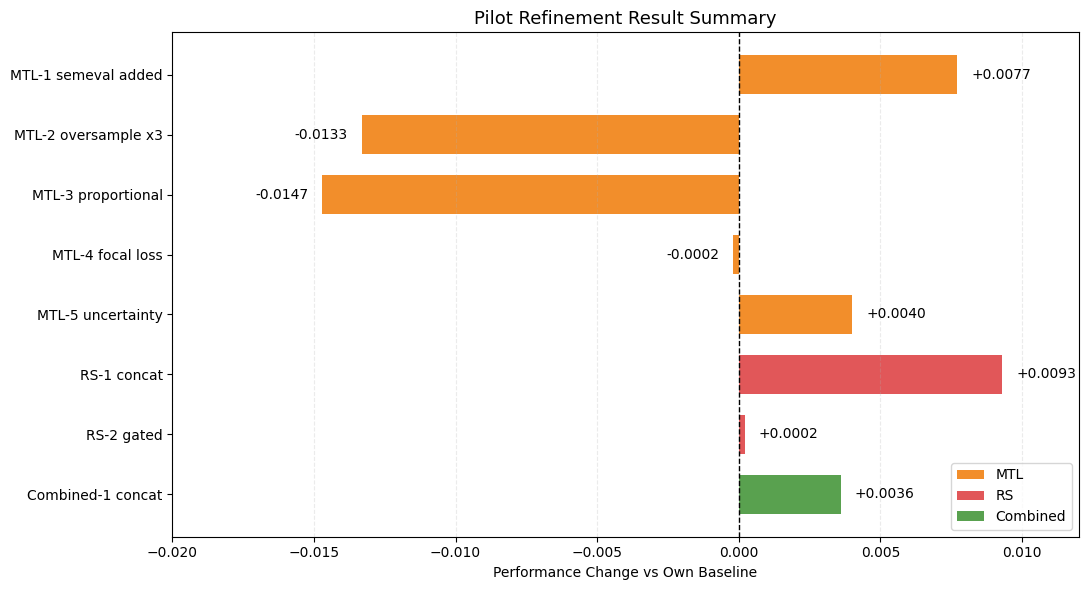

In [20]:
# Visualization: change vs. baseline

method_order = [
    "MTL-1 semeval added",
    "MTL-2 oversample x3",
    "MTL-3 proportional",
    "MTL-4 focal loss",
    "MTL-5 uncertainty",
    "RS-1 concat",
    "RS-2 gated",
    "Combined-1 concat"
]

plot_df = df_summary[~df_summary["change"].eq("Reference")].copy()

plot_df["delta_num"] = plot_df["change"].apply(
    lambda x: float(x.split(" ")[0])
)

def get_group(method):
    if method.startswith("MTL"):
        return "MTL"
    elif method.startswith("RS"):
        return "RS"
    else:
        return "Combined"

plot_df["group"] = plot_df["method"].apply(get_group)

COLORS = {
    "Baseline": "#4e79a7",
    "MTL": "#f28e2b",
    "RS": "#e15759",
    "Combined": "#59a14f"
}

plot_df["method"] = pd.Categorical(
    plot_df["method"],
    categories=method_order,
    ordered=True
)

plot_df = plot_df.sort_values("method", ascending=False)

fig, ax = plt.subplots(figsize=(11, 6))

bars = ax.barh(
    plot_df["method"].astype(str),
    plot_df["delta_num"],
    color=plot_df["group"].map(COLORS),
    height=0.65
)

ax.axvline(0, color="black", linestyle="--", linewidth=1)

for bar in bars:
    width = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2

    if width > 0:
        ax.text(width + 0.0005, y, f"{width:+.4f}",
                va="center", ha="left", fontsize=10)
    elif width < 0:
        ax.text(width - 0.0005, y, f"{width:+.4f}",
                va="center", ha="right", fontsize=10)
    else:
        ax.text(0.0005, y, f"{width:+.4f}",
                va="center", ha="left", fontsize=10)

ax.set_xlim(-0.020, 0.012)

ax.set_xlabel("Performance Change vs Own Baseline")
ax.set_ylabel("")
ax.set_title("Pilot Refinement Result Summary", fontsize=13)

ax.grid(axis="x", linestyle="--", alpha=0.25)

from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor=COLORS["MTL"], label="MTL"),
    Patch(facecolor=COLORS["RS"], label="RS"),
    Patch(facecolor=COLORS["Combined"], label="Combined"),
]

ax.legend(handles=legend_elements, loc="lower right")

plt.tight_layout()
plt.show()